# Frenos y embragues

In [1]:
import numpy as np
from tabulate import tabulate

Conversión de unidades:

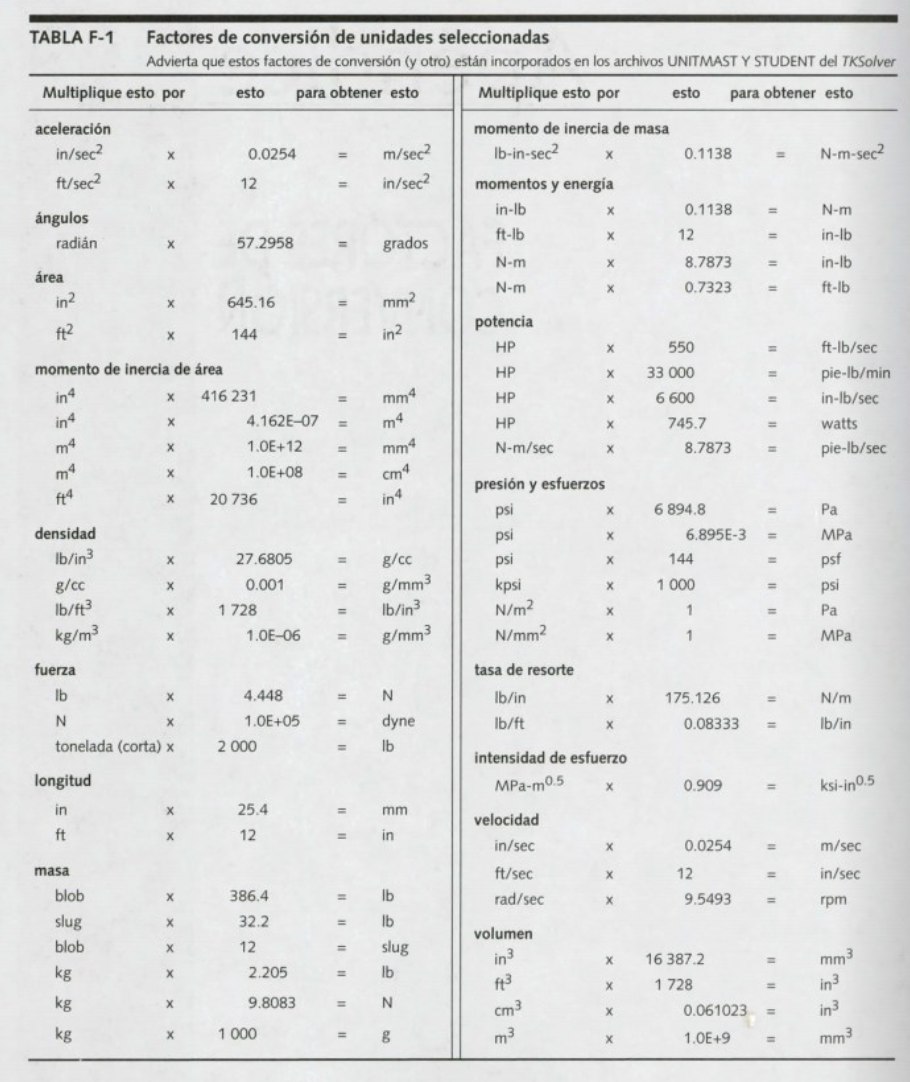

In [2]:
def inch_to_mm(value):
    return value * 25.4

def mm_to_inch(value):
    return value / 25.4

def rad_to_deg(value):
    return value * (180 / np.pi)

def deg_to_rad(value):
    return value * (np.pi / 180)

def rpm_to_radps(value):
    return value * (2 * np.pi / 60)

def radps_to_rpm(value):
    return value * (60 / (2 * np.pi))

def celsius_to_fahrenheit(celsius):
    return (celsius * 9/5) + 32

def fahrenheit_to_celsius(fahrenheit):
    return (fahrenheit - 32) * 5/9

def hp_to_watt(hp):
    return hp * 745.7

def psi_a_mpa(psi):
    return psi * 0.00689476

Coeficientes de fricción típicos:

![Captura de pantalla 2025-10-15 a la(s) 15.22.21.png](<attachment:Captura de pantalla 2025-10-15 a la(s) 15.22.21.png>)
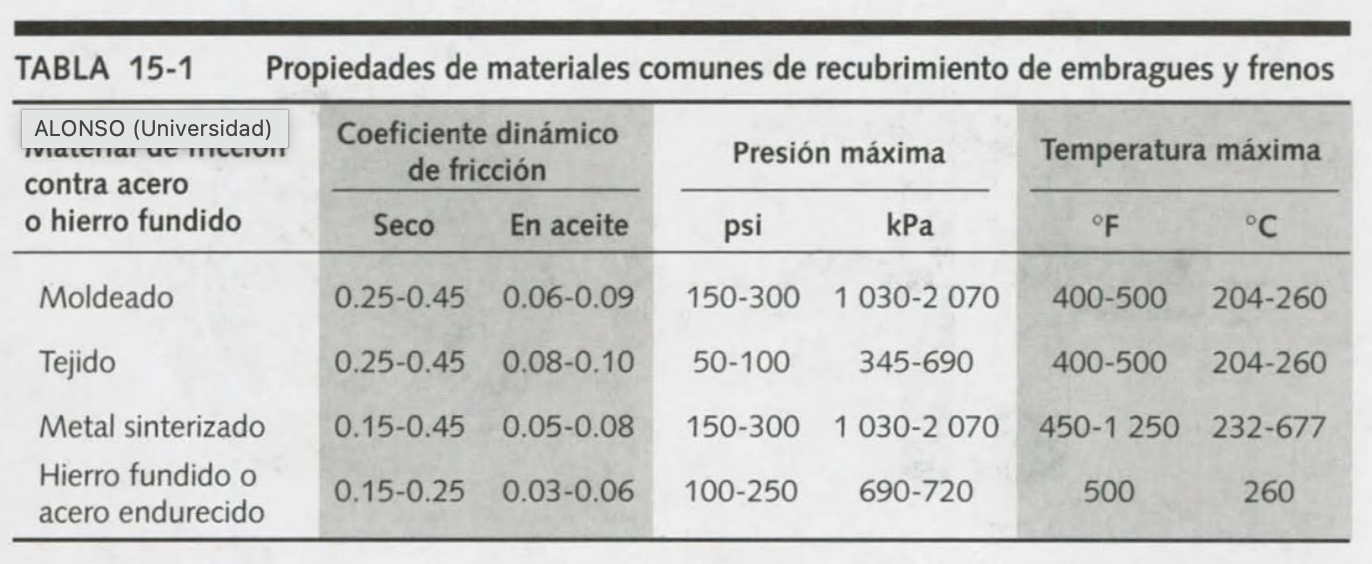

## Embragues de disco

Dos discos, uno de ellos recubierto con un material de alta fricción, comprimidos axialmente para generar la fuerza de fricción necesaria para transmitir par torsor. El desgaste es proporcional al producto entre la presión entre la superficies y la velocidad ($pV$). Puede darse el caso en el que la presión sea constante ($p$ = cte) o que el desgaste sea constante ($pV = $ cte).

![Captura de pantalla 2025-10-15 a la(s) 15.54.45.png](<attachment:Captura de pantalla 2025-10-15 a la(s) 15.54.45.png>)

**Embragues de disco: Desgaste uniforme**

Considerando que la velocidad es $V = r\omega$, se puede decir entonces que si $\omega$ es constante, entonces el producto $pr$ es constante. Es decir, en el radio interior $r_i$ necesariamente se debe encontrar la presión máxima $p_{max}$. Por tanto, se tiene la siguiente distribución de presiones:

$$
p(r) = p_{max}\frac{r_i}{r}
$$

De esta forma, considerando que un diferencial de fuerza axial es $dF_{axial} = 2\pi rdr$ y que un diferencial de momento transmitido es $dT = \mu r dF$ con $\mu$ el coeficiente de fricción, se tiene la siguiente expresión para la fuerza axial y momento torsor aplicado:

$$
F_{axial} = 2\pi p_{max} r_i (r_o - r_i)\\
M = \pi p_{max} \mu r_i (r_o^2 - r_i^2)
$$

Si se poseen $N$ caras de fricción, entonces el momento se debe multipicar por $N$ para obtener el momento total.

Derivando el momento con respecto al radio interior, se puede determinar que el radio interno que maximiza el par torsor es $r_i = \frac{1}{\sqrt{3}} r_o$. De esta forma, el par torsor máximo es:

$$
M_{max} = \frac{2\sqrt{3}}{9} \pi p_{max} \mu r_o^3
$$


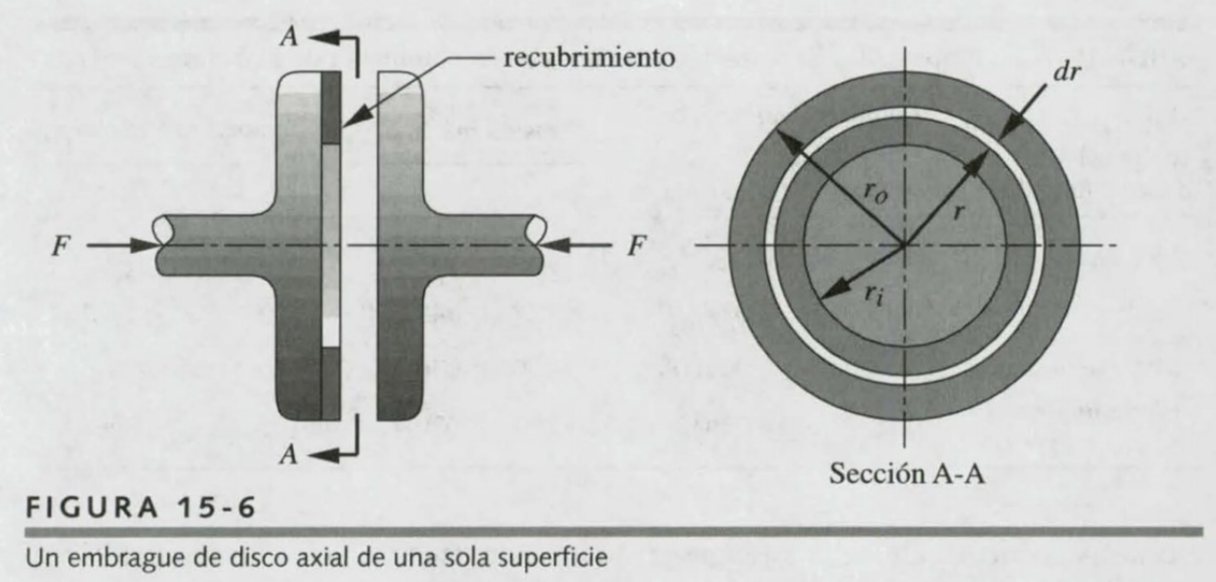

**Cálculo para el proyecto**

El embrague debe ser capaz de transmitir $80 \; [hp]$ a una velocidad de $1000 \; [rpm]$ con un factor de aplicación de $K_a = 3$. Para resolver este ejercicio se toma como referencia el ejemplo 15.1 del libro

In [4]:
H = hp_to_watt(80) * 3 # Se multiplica por el factor de aplicación
omega = rpm_to_radps(2500) # rad/s.
T = H / omega  # N*m
print(f"El torque que experimentará el embrague es: {T:.2f} N·m")
N = 3 # Número de superficies de fricción

# Seleccionaremos las propiedades promedios de un material seco moldeado
mu = (0.25 + 0.35) / 2
p_max = (345 + 690) / 2 * 1000 # Pa

# Despejar el radio externo requerido
r_o = ((9 * T) / (2 * np.sqrt(3) * np.pi * mu * p_max * N)) ** (1/3)
r_i = r_o / (np.sqrt(3))  # Radio interno
print(f"El radio externo requerido es: {r_o * 1000:.2f} mm")
print(f"El radio interno requerido es: {r_i * 1000:.2f} mm")
print(f"El diámetro mínimo del embrague es: {2 * r_o * 1000:.2f} mm")

El torque que experimentará el embrague es: 683.61 N·m
El radio externo requerido es: 106.67 mm
El radio interno requerido es: 61.59 mm
El diámetro mínimo del embrague es: 213.34 mm


## Frenos de disco

Los frenos de disco de mordazas son pastillas de fricción que se aplican sólo sobre una pequeña fracción de la circunferencia del disco. 

La fuerza de accionamiento accial está dada por:

$$
F = (\theta_2 - \theta_1) \int_{r_i}^{r_o} prdr
$$

Por su parte, el par de torsión generado por la fricción es:

$$
T = 2(\theta_2 - \theta_1) \mu \int_{r_i}^{r_o} pr^2dr
$$

## Frenos de tambor

Los frenos de tambor aplican el material de fricción contra la circunferencia de un cilindro (externa, interna o en ambas caras). Se denomina como zapata de freno es donde se monta el material de fricción, mientras que la pieza contra la que se frota es el tambor del freno.

Si bien puede ser interna o externa, se considera que una zapata es corta si $(\theta_2 - \theta_1) \leq 45°$, y se considera larga en otro caso.

### Frenos de zapata corta

Cuando se tiene que la extensión del arco de la zapata es menor a 45°, se puede asumir que la presión normal entre la zapata y el tambor es constante. De esta forma, la fuerza normal $F_n$, la fuerza de fricción $F_f$ y el par de torsión $T$ están dados por:

$$
F_n = p_{max} r\theta w \\
F_f = \mu F_n\\
T = F_fr
$$

Donde $w$ es el ancho de la zapata. Para accionar este freno es requerida una fuerza $F_a$ dada por:

$$
F_a = F_n \frac{b - \mu c}{a}
$$

Se dice que el freno es autoenergizado si la rotación dle tambor tiene el mismo sentido que el momento geneerado por $F_a$. Esto genera que se requiera una menor fuerza para accionar el freno.

Se dice que un freno es autobloqueante cuando es autoenergizante y $\mu c \geq b$

### Frenos de zapata larga

Cuando la zapata no es larga, no es correcto asumir que la presión normal es constante. Por tanto, se tendrá que la presión es proporcional a $\sin \theta$. De esta forma, la distribución de presión será de la siguiente forma:

$$
p = \frac{p_{max}}{\sin \theta_{max}} \sin \theta
$$

Donde $\theta_{max}$ es el ángulo más pequeño entre $\theta_2$ y 90°. De esta forma, los momentos que ejercen la fuerza normal y la fuerza de fricción con respecto a $O$ están dados por:

$$
M_{F_n} = \int b \sin \theta dF_n = wrb \frac{p_{max}}{\sin \theta_{max}} [\frac{1}{2}(\theta_2 - \theta_1) - \frac{1}{4}(\sin 2\theta_2 - \sin 2\theta_1)]
$$

$$
M_{F_f} = \int (r - b\cos \theta) dF_f = wrb \frac{p_{max}}{\sin \theta_{max}} [-r(\theta_2 - \theta_1) - \frac{b}{2}(\sin ^2 \theta_2 - \sin ^2 \theta_1)]
$$

De esta forma, la fuerza de accionamiento requerida está dada por:

$$
F_a = \frac{M_{F_n} - M_{F_f}}{a}
$$

Por su parte, el par de torsión debido a la fricción del freno está dado por:

$$
T = \int rdF_f =  \mu wr^2 \frac{p_{max}}{\sin \theta_{max}} (\theta_2 - \theta_1)
$$